In [1]:
import pandas as pd
import numpy as np

In [2]:
targets = pd.read_pickle("targets_DT.pkl")
means = targets[0]
sds = targets[1]

df = pd.DataFrame({
    "mean": pd.Series(means),
    "sd": pd.Series(sds)
})

df.index.name = "key"
df = df.reset_index()
df["accuracy"] = np.abs(df["mean"]) / df["sd"]

df

,key,mean,sd,accuracy
0,5,0.073995,0.001499,49.379095
1,20,0.057811,0.001318,43.860876
2,50,0.042631,0.001196,35.648018
3,100,0.025133,0.001105,22.743108
4,150,0.013313,0.001059,12.565387
5,200,0.004693,0.001033,4.541304


In [3]:
import glob
import pandas as pd

combined_df = pd.concat(
    [pd.read_pickle(f) for f in sorted(glob.glob("pickles/*.pkl"))],
    ignore_index=True
)

In [4]:
combined_df.to_pickle("combined_DT.pkl")

In [5]:
k = 2
stat = "V"
d_mult = 0.75
B = 2

df_filtered = combined_df[
    (combined_df["k"] == 2) &
    (combined_df["stat"] == stat) &
    (combined_df["D_mult"] <= 0.5) &
    (combined_df["B"] <= 2)
]

df_filtered

,k,stat,n,d,D_mult,B,coverage,average length,n_jobs,simul_size
700,2,V,2,1,0.01,1,0.439583,12.508454,8,480
701,2,V,2,1,0.10,1,0.439583,12.508454,8,480
702,2,V,2,1,0.50,1,0.439583,12.508454,8,480
705,2,V,1002,10,0.01,1,0.972917,7.887834,8,480
706,2,V,1002,100,0.10,1,0.966667,2.770399,8,480
707,2,V,1002,501,0.50,1,0.960417,1.415237,8,480
710,2,V,2001,20,0.01,1,0.972917,6.495436,8,480
711,2,V,2001,200,0.10,1,0.977083,1.994675,8,480
712,2,V,2001,1000,0.50,1,0.970833,1.033688,8,480
715,2,V,3000,30,0.01,1,0.966667,5.024278,8,480


In [6]:
df_filtered = combined_df[
    (combined_df["d"] <= 10) &
    (combined_df["stat"] == stat) &
    (combined_df["B"] <= 2)
]

df_filtered

,k,stat,n,d,D_mult,B,coverage,average length,n_jobs,simul_size
0,100,V,100,1,0.01,2,0.962500,6.131257,4,480
1,100,V,100,10,0.10,2,0.933333,2.955986,4,480
100,300,V,300,3,0.01,1,0.956250,10.110955,4,480
150,300,V,300,3,0.01,2,0.950000,3.633637,4,480
275,500,V,500,5,0.01,1,0.968750,8.351966,4,480
325,500,V,500,5,0.01,2,0.956250,3.095435,4,480
425,1000,V,1000,10,0.01,1,0.933333,6.599204,6,480
475,1000,V,1000,10,0.01,2,0.950000,2.515880,6,480
500,50,V,50,1,0.01,1,0.960417,17.684737,4,480
501,50,V,50,5,0.10,1,0.952083,9.364295,4,480


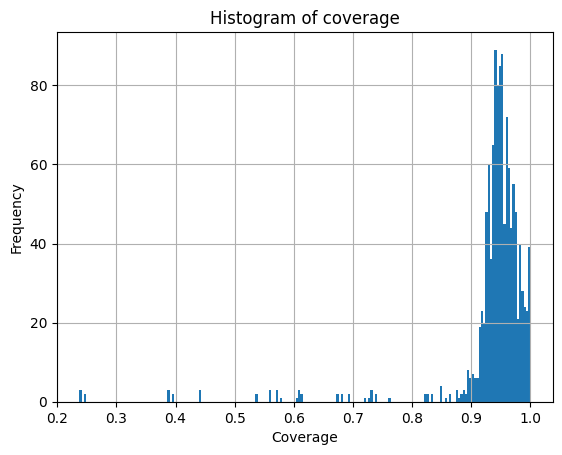

In [7]:
import matplotlib.pyplot as plt

combined_df['coverage'].hist(bins=200)
plt.xlabel("Coverage")
plt.ylabel("Frequency")
plt.title("Histogram of coverage")
plt.show()